# Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Introdução

In [47]:
# Função que será usada para plotar os gráficos
def plot_decision_regions(clf, X, y, title=""):
    x1min, x1max = X[:,0].min()-0.5, X[:,0].max()+0.5
    x2min, x2max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1min, x1max, 400),
                           np.linspace(x2min, x2max, 400))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = clf.predict(grid).reshape(xx1.shape)
    plt.figure()
    plt.contourf(xx1, xx2, Z, alpha=0.25)
    plt.scatter(X[:,0], X[:,1], c=y, s=12, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

In [48]:
# Geração dos dados
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

# DataFrame com rótulos de cada lua
df = pd.DataFrame({
    "x1": X[:, 0],
    "x2": X[:, 1],
    "y": y,
    "label": np.where(y == 0, "Lua A", "Lua B")
})

print(df.head())

         x1        x2  y  label
0  0.625460  1.039122  0  Lua A
1  0.698887 -0.434031  1  Lua B
2  1.577001  0.054440  1  Lua B
3  0.911745  0.665198  0  Lua A
4 -0.313873  0.651696  0  Lua A


# Regressão Logística

In [54]:
# Divisão em treino e teste (20% para teste)
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Pipeline: padronização + regressão logística
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, solver="saga"))  # saga suporta l1 e l2
])

# Configuração da validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid separado para L1 e L2
param_grid_split = {
    "l1": {"model__penalty": ["l1"], "model__C": np.logspace(-3, 3, 13)},
    "l2": {"model__penalty": ["l2"], "model__C": np.logspace(-3, 3, 13)},
}

# Dicionário para armazenar resultados
results = {}
for pen, grid in param_grid_split.items():
    gs_pen = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
    gs_pen.fit(X_train, y_train)
    mdl = gs_pen.best_estimator_.named_steps["model"]
    coefs = mdl.coef_.ravel()
    results[pen] = {
        "best_C": mdl.C,
        "cv_auc": gs_pen.best_score_,
        "test_auc": roc_auc_score(y_test, gs_pen.predict_proba(X_test)[:, 1]),
        "test_acc": accuracy_score(y_test, gs_pen.predict(X_test)),
        "non_zero": int(np.count_nonzero(coefs)),
        "total_features": coefs.size,
        "best_estimator": gs_pen.best_estimator_
    }

## Regressão Lasso

~~~ Regressão Logística L1 (Lasso) ~~~
Melhor C: 0.1
CV AUC: 0.9378
Test AUC: 0.9403
Test Accuracy: 0.8750
Número de coeficientes não nulos: 2/2


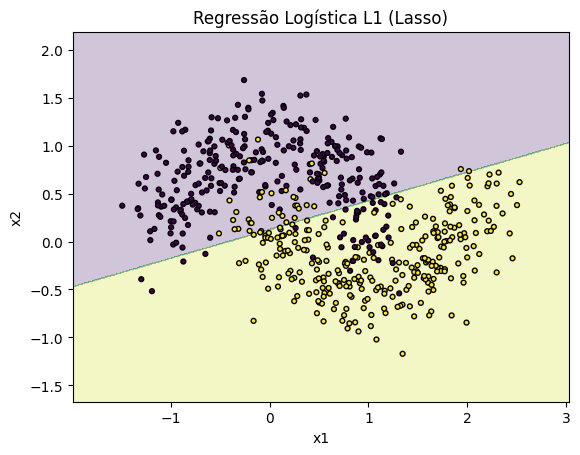

In [50]:
# Resultados L1 (Lasso)
r_l1 = results["l1"]
print("~~~ Regressão Logística L1 (Lasso) ~~~")
print(f"Melhor C: {r_l1['best_C']}")
print(f"CV AUC: {r_l1['cv_auc']:.4f}")
print(f"Test AUC: {r_l1['test_auc']:.4f}")
print(f"Test Accuracy: {r_l1['test_acc']:.4f}")
print(f"Número de coeficientes não nulos: {r_l1['non_zero']}/{r_l1['total_features']}")


# Melhor modelo L1
best_l1 = GridSearchCV(pipe, param_grid_split["l1"], scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
best_l1.fit(X_train, y_train)
plot_decision_regions(best_l1.best_estimator_, X, y, title="Regressão Logística L1 (Lasso)")

## Regressão Ridge

~~~ Regressão Logística L2 (Ridge) ~~~
Melhor C: 0.1
CV AUC: 0.9389
Test AUC: 0.9403
Test Accuracy: 0.8750
Número de coeficientes não nulos: 2/2


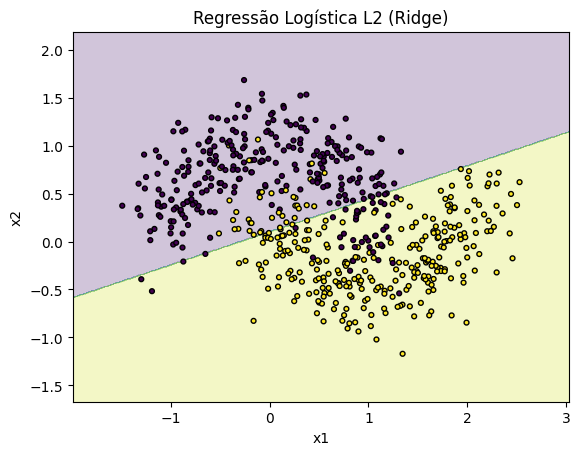

In [51]:
# Resultados L2 (Ridge)
r_l2 = results["l2"]
print("~~~ Regressão Logística L2 (Ridge) ~~~")
print(f"Melhor C: {r_l2['best_C']}")
print(f"CV AUC: {r_l2['cv_auc']:.4f}")
print(f"Test AUC: {r_l2['test_auc']:.4f}")
print(f"Test Accuracy: {r_l2['test_acc']:.4f}")
print(f"Número de coeficientes não nulos: {r_l2['non_zero']}/{r_l2['total_features']}")

# Melhor modelo L2
best_l2 = GridSearchCV(pipe, param_grid_split["l2"], scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
best_l2.fit(X_train, y_train)
plot_decision_regions(best_l2.best_estimator_, X, y, title="Regressão Logística L2 (Ridge)")


# SVM com kernel RBF

~~~ SVM com kernel RBF ~~~
Melhores parâmetros: {'C': 5, 'gamma': 1.0}
CV AUC: 0.9350
Test AUC: 0.9886
Test Accuracy: 0.9333


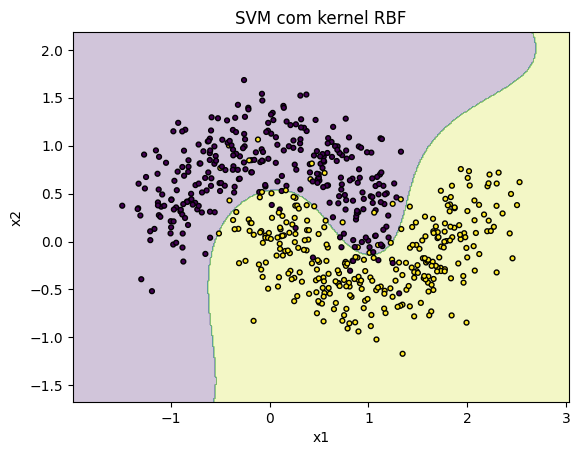

In [70]:
param_grid = {"C": [0.5, 1, 5, 10], "gamma": [0.2, 0.5, 1.0, 2.0]}
clf = GridSearchCV(SVC(kernel="rbf", probability=True), param_grid, cv=3, n_jobs=-1, refit=True) # Probability=True para usar predict_proba
clf.fit(X, y)
best = clf.best_estimator_

# Dicionário para armazenar resultados SVM RBF
results["svm_rbf"] = {
    "best_params": clf.best_params_,
    "cv_auc": clf.best_score_,
    "test_auc": roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]),
    "test_acc": accuracy_score(y_test, clf.predict(X_test)),
    "best_estimator": clf.best_estimator_
}

# Resultados SVM RBF
r_svm = results["svm_rbf"]
print("~~~ SVM com kernel RBF ~~~")
print(f"Melhores parâmetros: {r_svm['best_params']}")
print(f"CV AUC: {r_svm['cv_auc']:.4f}")
print(f"Test AUC: {r_svm['test_auc']:.4f}")
print(f"Test Accuracy: {r_svm['test_acc']:.4f}")

# Melhor modelo SVM RBF
plot_decision_regions(best, X, y, title=f"SVM com kernel RBF")

# Comparação

~~~ Comparação dos modelos ~~~

Modelo: l1
  best_C: 0.1
  cv_auc: 0.9378472222222222
  test_auc: 0.9402777777777778
  test_acc: 0.875
  non_zero: 2
  total_features: 2

Modelo: l2
  best_C: 0.1
  cv_auc: 0.9388888888888889
  test_auc: 0.9402777777777778
  test_acc: 0.875
  non_zero: 2
  total_features: 2

Modelo: svm_rbf
  best_params: {'C': 5, 'gamma': 1.0}
  cv_auc: 0.9349999999999999
  test_auc: 0.9886111111111111
  test_acc: 0.9333333333333333


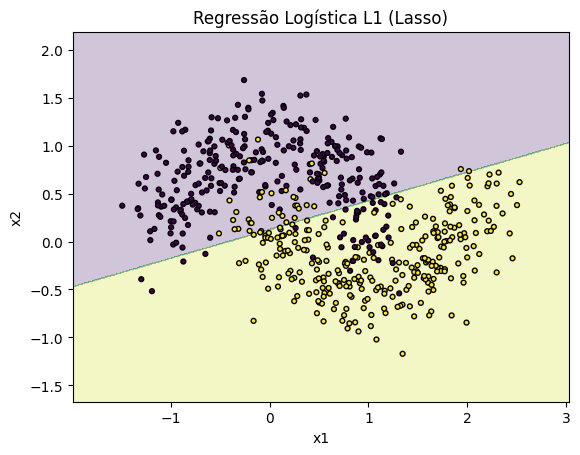

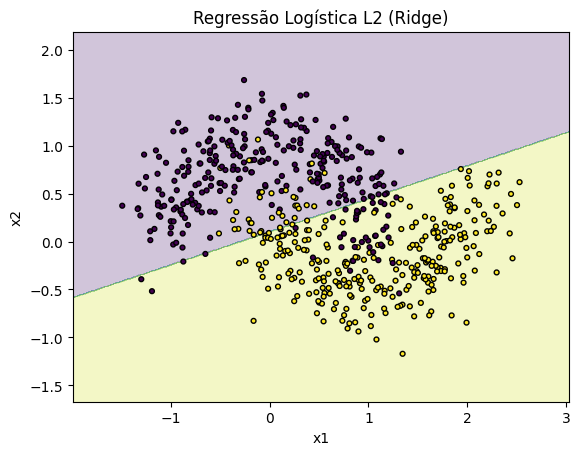

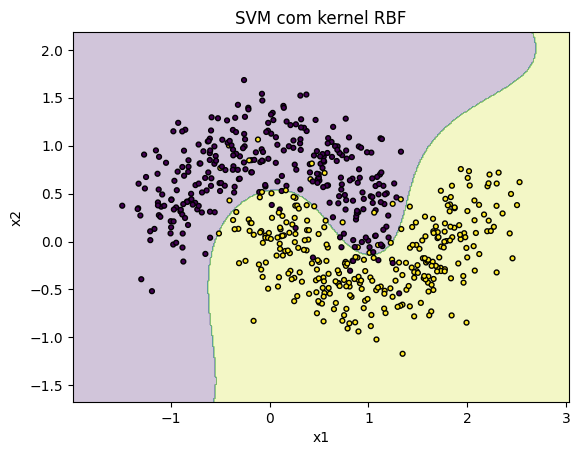

In [71]:
print("~~~ Comparação dos modelos ~~~")

for model_name, res in results.items():
    print(f"\nModelo: {model_name}")
    for metric, value in res.items():
        if metric != "best_estimator":
            print(f"  {metric}: {value}")

plot_decision_regions(best_l1.best_estimator_, X, y, title="Regressão Logística L1 (Lasso)")
plot_decision_regions(best_l2.best_estimator_, X, y, title="Regressão Logística L2 (Ridge)")
plot_decision_regions(best, X, y, title=f"SVM com kernel RBF")

##  Desempenho de cada modelo

- L1: Possui boa performance, porém é limitado pela linearidade, impedindo uma separação eficiente em dados com padrões não lineares, como o conjunto moons.
- L2: Não faz tanta diferença do L1 para o L2, mas se tiver que escolher entre esses o L2 é minimamente mais preciso, já que encolhe os coeficientes ao invés de zerá-los.
- SVM RBF: Consegue modelar fronteiras não lineares, adaptando-se ao formato das classes. Dessa forma, possui maior acurácia e AUC no conjunto de teste, além de uma separação visualmente mais eficiente entre as duas “luas”.

## Diferenças nas métricas e nas fronteiras de decisão.

- Métricas:
    - L1: Boa precisão → cv_auc ≈ 0.938, test_auc ≈ 0.940 e test_acc = 0.875
    - L2: Muito próximas ao L1 → cv_auc ≈ 0.939, test_auc ≈ 0.940 e test_acc = 0.875
    - SVM RBF:
        - cv_auc ≈ 0.935 → similar à regressão logística na validação cruzada.
        - Mas no teste: test_auc ≈ 0.989 e test_acc ≈ 0.933 → desempenho muito superior.

- Fronteiras:
    - L1: Linear, ou seja, uma reta separando as duas classes. Não consegue se adaptar ao formato curvo das “luas”, então há erros nas regiões onde elas se entrelaçam.
    - L2: Linear, igual ao L1. A diferença está na regularização, pois ele encolhe os coeficientes em vez de zerá-los, trazendo mais estabilidade.
    - SVM RBF: Não linear, é uma curva que se adapta ao formato das duas luas. Consegue contornar cada classe, separando-as de forma quase perfeita.